## PyTorch Benchmark — Hands-on Workshop

**241-353 AI Ecosystem · Prince of Songkla University**

Companion to `pytorch_profiler_workshop.ipynb`. Every cell runs on a laptop CPU.

---

### Two tools, two questions

| | `torch.profiler` | `torch.utils.benchmark` |
|---|---|---|
| Answers | **Where** does the time go? | **How much** time is there? |
| Output | Per-operator breakdown, timeline | One number, with error bars |
| Overhead | High — it instruments every op | Low — it just runs your code |
| Use it to | Find the bottleneck | Prove you fixed it |

You need both, and in this order: **benchmark to detect, profile to diagnose, benchmark to
confirm.** A profiler total is not a latency number — it includes tracing overhead. A
benchmark number tells you nothing about *why*.

```mermaid
flowchart LR
    classDef default fill:#ffffff,stroke:#57606a,stroke-width:1px,color:#1f2328;
    A["Is it fast enough?<br/>torch.utils.benchmark"] -->|"no"| B["Where does time go?<br/>torch.profiler"]
    B --> C["Change one thing"]
    C --> D["Did it actually help?<br/>torch.utils.benchmark"]
    D -->|"no, or not significantly"| B
    D -->|"yes"| E["Ship it"]
    A -->|"yes"| E
```

> Diagrams are [Mermaid](https://mermaid.js.org). JupyterLab 4.1+, VS Code and GitHub render
> them inline; otherwise paste the block into <https://mermaid.live>.

### Structure

| Part | Topic |
|---|---|
| **0** | Setup and styling |
| **1** | Why `time.perf_counter()` lies to you |
| **2** | `Timer` — the core API |
| **3** | `Measurement` — reading a result honestly |
| **4** | `Compare` — benchmark matrices |
| **5** | Benchmarking **inference** |
| **6** | Benchmarking **training** |
| **7** | Advanced: `Fuzzer`, C++ timing, Callgrind |
| **8** | Workflow, checklist, exercises |

### How to run

```bash
python3.13 -m venv .venv
source .venv/bin/activate
pip install -r requirements.txt
jupyter lab
```

Total runtime is a few minutes — benchmarking deliberately takes real wall-clock time.
**Close other applications before running.** Every number here is sensitive to background
load, and Part 1.4 shows you exactly how sensitive.

---
## Part 0 — Setup

### 0.1 Notebook styling (optional)

Pulls markdown down to roughly the code font size. Cosmetic only.

In [1]:
from IPython.display import HTML, display

display(HTML("""
<style>
.jp-RenderedMarkdown,
.jp-MarkdownCell .jp-RenderedHTMLCommon,
div[data-mime-type="text/markdown"],
.markdown-body { font-size: 13px; line-height: 1.55; }
.jp-RenderedMarkdown h1, .markdown-body h1 { font-size: 1.55em; margin: .7em 0 .45em; }
.jp-RenderedMarkdown h2, .markdown-body h2 { font-size: 1.28em; margin: .7em 0 .4em; }
.jp-RenderedMarkdown h3, .markdown-body h3 { font-size: 1.10em; margin: .6em 0 .35em; }
.jp-RenderedMarkdown h4, .markdown-body h4 { font-size: 1.00em; margin: .6em 0 .3em; }
.jp-RenderedMarkdown table, .markdown-body table { font-size: .92em; }
.jp-RenderedMarkdown th, .jp-RenderedMarkdown td { padding: 3px 8px; }
.jp-RenderedMarkdown pre, .jp-RenderedMarkdown code { font-size: .95em; }
</style>
"""))
print("styling applied")

styling applied


### 0.2 Environment

Benchmark numbers are meaningless without the machine they came from. Record this.

In [2]:
import os, sys, time, timeit, math, platform, statistics, contextlib, warnings
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import pandas as pd
import torch.utils.benchmark as benchmark
from torch.utils.benchmark import Timer, Compare, Measurement

pd.set_option("display.width", 200)

# Silence one torch warning that fires when profiling with a `schedule` but no `acc_events`.
# That is deliberate where it happens here; the warning only adds a long absolute path.
warnings.filterwarnings("ignore", message=".*Profiler clears events.*")

print(f"python      : {sys.version.split()[0]}")
print(f"torch       : {torch.__version__}")
print(f"platform    : {platform.platform()}  ({platform.machine()})")
print(f"CPU threads : intra-op={torch.get_num_threads()}  inter-op={torch.get_num_interop_threads()}")
print(f"accelerator : {torch.accelerator.current_accelerator() if torch.accelerator.is_available() else 'none'}")
print(f"MPS         : {torch.backends.mps.is_available()}")
print(f"CUDA        : {torch.cuda.is_available()}")

python      : 3.13.15
torch       : 2.14.0
platform    : macOS-27.0-arm64-arm-64bit-Mach-O  (arm64)
CPU threads : intra-op=4  inter-op=8
accelerator : mps
MPS         : True
CUDA        : False


### 0.3 The models

The same three architectures as the profiler workshop, imported from `ws_models.py` so this
notebook can stay about benchmarking. `S6Naive` and `S6Fast` are two implementations of the
Mamba selective scan that compute **identical values** with different operator granularity —
a perfect A/B subject.

In [3]:
sys.path.insert(0, str(Path.cwd()))
from ws_models import TinyViT, TinyVisionMamba, S6Naive, S6Fast, nparams

torch.manual_seed(0)

resnet = torchvision.models.resnet18(weights=None).eval()
mobilenet = torchvision.models.mobilenet_v3_small(weights=None).eval()
vit    = TinyViT().eval()
mamba_naive = TinyVisionMamba(mixer_cls=S6Naive).eval()
mamba_fast  = TinyVisionMamba(mixer_cls=S6Fast).eval()
mamba_fast.load_state_dict(mamba_naive.state_dict())      # same weights -> fair A/B

X_IMG  = torch.randn(4, 3, 224, 224)      # for resnet / vit
X_SMALL = torch.randn(4, 3, 64, 64)       # for mamba

with torch.inference_mode():
    agree = torch.allclose(mamba_naive(X_SMALL), mamba_fast(X_SMALL))

for name, m in [("ResNet-18", resnet), ("MobileNetV3-Small", mobilenet), ("ViT-Tiny", vit),
                ("Mamba (S6Naive)", mamba_naive), ("Mamba (S6Fast)", mamba_fast)]:
    print(f"{name:<19} {nparams(m)/1e6:6.2f} M params")
print(f"\nS6Naive and S6Fast agree numerically: {agree}")

ResNet-18            11.69 M params
MobileNetV3-Small     2.54 M params
ViT-Tiny              2.86 M params
Mamba (S6Naive)       0.16 M params
Mamba (S6Fast)        0.16 M params

S6Naive and S6Fast agree numerically: True


---
## Part 1 — Why `time.perf_counter()` lies to you

Everyone writes this function at some point:

```python
t0 = time.perf_counter()
model(x)
print(time.perf_counter() - t0)
```

It has **five** independent failure modes. Each one below is demonstrated, and
`torch.utils.benchmark.Timer` handles all five for you.

### 1.1 Failure 1 — no warmup

The first call pays for lazy kernel selection, allocator growth and cold caches.

In [4]:
def naive_time(fn, n=1):
    t0 = time.perf_counter()
    for _ in range(n):
        fn()
    return (time.perf_counter() - t0) / n * 1e3          # ms


fresh = torchvision.models.resnet18(weights=None).eval()
with torch.inference_mode():
    first = naive_time(lambda: fresh(X_IMG))
    later = naive_time(lambda: fresh(X_IMG), n=10)

print(f"first call  : {first:7.1f} ms")
print(f"next 10 avg : {later:7.1f} ms")
print(f"inflation   : {first/later:7.2f}x")

first call  :    29.2 ms
next 10 avg :    32.0 ms
inflation   :    0.91x


### 1.2 Failure 2 — one sample is not a measurement

A single timing is a random draw. Run the *same* code 10 times and look at the spread.

In [5]:
with torch.inference_mode():
    samples = [naive_time(lambda: resnet(X_IMG)) for _ in range(10)]

s = pd.Series(samples)
print(f"min {s.min():.1f}  median {s.median():.1f}  max {s.max():.1f} ms")
print(f"spread: max is {s.max()/s.min():.2f}x the min")
print("\nIf you run your benchmark once and your colleague runs it once,")
print("you can 'prove' a change of this size without changing anything.")

min 34.7  median 35.1  max 36.1 ms
spread: max is 1.04x the min

If you run your benchmark once and your colleague runs it once,
you can 'prove' a change of this size without changing anything.


### 1.3 Failure 3 — no accelerator synchronisation

**This is the one that produces genuinely absurd numbers.** GPU work is dispatched
asynchronously: the Python call returns as soon as the work is *queued*, not when it is
*done*. Timing it without synchronising measures how fast you can fill a queue.

In [6]:
if torch.backends.mps.is_available():
    dev = "mps"
    a = torch.randn(2048, 2048, device=dev)
    b = torch.randn(2048, 2048, device=dev)

    with torch.inference_mode():
        for _ in range(5):                                   # warmup
            a @ b
        torch.mps.synchronize()

        no_sync = statistics.median(
            [naive_time(lambda: a @ b) for _ in range(20)])

        def synced():
            a @ b
            torch.mps.synchronize()
        with_sync = statistics.median([naive_time(synced) for _ in range(20)])

        auto = Timer(stmt="a @ b", globals={"a": a, "b": b}
                     ).blocked_autorange(min_run_time=0.5).median * 1e3

    print(f"naive, no synchronize : {no_sync:9.3f} ms   <- FICTION")
    print(f"naive, manual sync    : {with_sync:9.3f} ms")
    print(f"benchmark.Timer       : {auto:9.3f} ms   <- synchronised for you")
    print(f"\nthe unsynchronised number is {with_sync/no_sync:.0f}x too fast")
else:
    print("No MPS on this machine - on CPU every op is synchronous, so this failure")
    print("mode cannot be demonstrated here. It bites hard on CUDA and MPS.")

naive, no synchronize :     0.026 ms   <- FICTION
naive, manual sync    :     6.172 ms
benchmark.Timer       :     5.891 ms   <- synchronised for you

the unsynchronised number is 241x too fast


`Timer`'s default clock is not `time.perf_counter`. It is:

```python
def timer() -> float:
    if torch.accelerator.is_available():
        torch.accelerator.synchronize()
    return timeit.default_timer()
```

So **the moment an accelerator is present, `Timer` synchronises for you.** You cannot
forget. This alone justifies using it.

### 1.4 Failure 4 — your machine is not a controlled environment

Run the identical benchmark twice, minutes apart, and the numbers move: other processes,
CPU frequency scaling, thermal throttling, cache state. The honest question is never
"is A faster than B?" but **"is A faster than B by more than my machine's own noise?"**

Part 3 shows how to answer that properly. For now, the null experiment: benchmark the same
thing twice and see what "no change at all" looks like.

In [7]:
def bench_op(label):
    return Timer(stmt="resnet(X_IMG)", globals={"resnet": resnet, "X_IMG": X_IMG},
                 label="null experiment", sub_label="ResNet-18 fwd",
                 description=label).blocked_autorange(min_run_time=0.4)


with torch.inference_mode():
    run_a, run_b = bench_op("run A"), bench_op("run B")

print(f"run A median: {run_a.median*1e3:.2f} ms   IQR {run_a.iqr*1e3:.2f} ms")
print(f"run B median: {run_b.median*1e3:.2f} ms   IQR {run_b.iqr*1e3:.2f} ms")
delta = 100 * (run_b.median - run_a.median) / run_a.median
print(f"\napparent 'change' from changing nothing: {delta:+.1f}%")
print("Any optimisation claiming less than this is indistinguishable from noise.")

run A median: 54.39 ms   IQR 3.66 ms
run B median: 53.67 ms   IQR 0.28 ms

apparent 'change' from changing nothing: -1.3%
Any optimisation claiming less than this is indistinguishable from noise.


### 1.5 Failure 5 — uncontrolled thread count

PyTorch defaults to using every core. If your benchmark and your production server disagree
about thread count, your benchmark is measuring a different machine. `Timer` takes
`num_threads` explicitly and restores the previous setting afterwards.

### 1.6 Summary

| Failure | Naive timing | `benchmark.Timer` |
|---|---|---|
| No warmup | you must remember | handled |
| Single sample | you must loop | adaptive replication |
| Accelerator async | silently 100x wrong | synchronised automatically |
| Machine noise | invisible | reported as IQR |
| Thread count | inherited, unstated | explicit `num_threads` |
| Comparing runs | manual bookkeeping | `Compare` tables |

---
## Part 2 — `Timer`, the core API

### 2.1 Anatomy

```python
Timer(
    stmt        = "model(x)",       # the code to time, as a STRING
    setup       = "pass",           # run once per replicate, not timed
    globals     = {"model": m, "x": x},   # names visible to stmt
    label       = "ResNet-18",      # table title in Compare
    sub_label   = "batch 4",        # ROW in Compare
    description = "eager fp32",     # COLUMN in Compare
    num_threads = 1,                # intra-op threads during measurement
)
```

Two things trip people up:

1. **`stmt` is a string, not a callable.** It is `exec`'d in a namespace built from
   `globals`. A name you forget to pass raises `NameError` at run time.
2. **`setup` runs once per replicate and is not timed**, so it is where data creation goes.
   Anything in `stmt` *is* timed — including indexing, `.to()` and `.item()`.

### 2.2 Three ways to run it

| Method | What it does | Use when |
|---|---|---|
| `timeit(n)` | Runs `stmt` `n` times, returns one measurement | You already know a good `n` |
| `blocked_autorange(min_run_time=t)` | Picks `n` automatically, repeats until `t` seconds elapsed, returns many replicates | **Default choice** |
| `adaptive_autorange(threshold=r)` | Keeps sampling until the result is stable to within `r` relative IQR | Noisy environments, or you want a confidence guarantee |

In [8]:
t = Timer(stmt="resnet(X_IMG)",
          globals={"resnet": resnet, "X_IMG": X_IMG},
          label="ResNet-18", sub_label="batch 4", description="eager fp32",
          num_threads=torch.get_num_threads())

with torch.inference_mode():
    m_timeit   = t.timeit(20)
    m_blocked  = t.blocked_autorange(min_run_time=0.5)
    m_adaptive = t.adaptive_autorange(threshold=0.05, min_run_time=0.1, max_run_time=3.0)

for name, m in [("timeit(20)", m_timeit),
                ("blocked_autorange(0.5)", m_blocked),
                ("adaptive_autorange(0.05)", m_adaptive)]:
    print(f"{name:<26} median {m.median*1e3:6.2f} ms   "
          f"{len(m.times):>3} replicates x {m.number_per_run} runs")

timeit(20)                 median  35.42 ms     1 replicates x 20 runs
blocked_autorange(0.5)     median  35.36 ms    15 replicates x 1 runs
adaptive_autorange(0.05)   median  35.58 ms     4 replicates x 1 runs


Note `number_per_run`: `blocked_autorange` decided how many iterations to put inside each
timed block so the block is long enough to dominate clock granularity, then repeated that
block many times. **The replicates are what give you an error bar** — `timeit()` returns one
replicate and therefore no error bar at all.

### 2.3 `setup` vs `stmt` — a demonstration of getting it wrong

What you put in `stmt` is what you measure. Here the "benchmark" accidentally includes
tensor allocation, which is a completely different question.

In [9]:
wrong = Timer(stmt="x = torch.randn(4, 3, 224, 224); resnet(x)",
              setup="import torch", globals={"resnet": resnet}
              ).blocked_autorange(min_run_time=0.4)

right = Timer(stmt="resnet(x)",
              setup="import torch; x = torch.randn(4, 3, 224, 224)",
              globals={"resnet": resnet}).blocked_autorange(min_run_time=0.4)

print(f"stmt includes torch.randn : {wrong.median*1e3:6.2f} ms")
print(f"allocation in setup       : {right.median*1e3:6.2f} ms")
print(f"difference                : {(wrong.median-right.median)*1e3:6.2f} ms of input creation")

stmt includes torch.randn :  58.87 ms
allocation in setup       :  54.10 ms
difference                :   4.77 ms of input creation


Neither is *wrong* as such — they answer different questions. The mistake is not knowing
which one you asked. If you are benchmarking a serving endpoint, input preparation belongs
in `stmt`. If you are comparing two model implementations, it does not.

### 2.4 `num_threads`

`Timer` sets the intra-op thread count for the duration of the measurement and restores it
afterwards, so a sweep does not leak state into the rest of your notebook.

In [10]:
print(f"threads before: {torch.get_num_threads()}")

rows = []
with torch.inference_mode():
    for th in [1, 2, 4, torch.get_num_threads()]:
        m = Timer(stmt="resnet(X_IMG)", globals={"resnet": resnet, "X_IMG": X_IMG},
                  num_threads=th).blocked_autorange(min_run_time=0.4)
        rows.append({"threads": th, "median_ms": m.median * 1e3, "iqr_ms": m.iqr * 1e3})

df = pd.DataFrame(rows).drop_duplicates(subset="threads")
df["speedup_vs_1"] = df.median_ms.iloc[0] / df.median_ms
df["efficiency_%"] = 100 * df.speedup_vs_1 / df.threads
display(df.round(2))
print(f"threads after : {torch.get_num_threads()}  (restored)")

threads before: 4


,threads,median_ms,iqr_ms,speedup_vs_1,efficiency_%
0,1,53.63,0.29,1.00,100.00
1,2,46.74,0.70,1.15,57.37
2,4,36.04,0.51,1.49,37.20


threads after : 4  (restored)


Read the `efficiency_%` column: perfect scaling would be 100%. Real convolutions never
reach it — memory bandwidth, thread launch cost, and on Apple Silicon the fact that not all
cores are performance cores. **Knowing your scaling efficiency tells you whether to run one
big process or several small ones.**

---
## Part 3 — `Measurement`: reading a result honestly

`blocked_autorange` returns a `Measurement`, which is a distribution, not a number.
`print()` it to get the human-readable form — **do not just `display()` it**, since the
plain repr is an object address.

In [11]:
with torch.inference_mode():
    m = Timer(stmt="vit(X_IMG)", globals={"vit": vit, "X_IMG": X_IMG},
              label="ViT-Tiny", sub_label="batch 4", description="eager fp32",
              num_threads=torch.get_num_threads()).blocked_autorange(min_run_time=1.0)

print(m)

ViT-Tiny: batch 4
eager fp32
  Median: 10.29 ms
  IQR:    0.05 ms (10.26 to 10.32)
  10 measurements, 10 runs per measurement, 4 threads


### 3.1 The fields that matter

| Field | Meaning | When to use |
|---|---|---|
| `.median` | Middle replicate | **Report this.** Robust to outliers. |
| `.mean` | Average | Only if you care about total throughput over a run |
| `.iqr` | Interquartile range (p75 − p25) | Your error bar |
| `.times` | Per-iteration time of each replicate | Plot it, inspect the distribution |
| `.number_per_run` | Iterations inside one timed block | Sanity-check the clock resolution |
| `.significant_figures` | Digits the spread actually justifies | Stops you quoting `12.3847 ms` |
| `.meets_confidence(t)` | Is `iqr/median < t`? | Gate before trusting a comparison |
| `.has_warnings` | Did the run look unstable? | Check it |

In [12]:
print(f"median              : {m.median*1e3:.4f} ms")
print(f"mean                : {m.mean*1e3:.4f} ms   (mean > median => right-tailed outliers)")
print(f"IQR                 : {m.iqr*1e3:.4f} ms  ({100*m.iqr/m.median:.1f}% of median)")
print(f"replicates          : {len(m.times)}  x {m.number_per_run} iterations each")
print(f"significant figures : {m.significant_figures}  -> quote it as "
      f"{m.median*1e3:.{max(m.significant_figures-2,0)}f} ms")
print(f"meets_confidence(5%): {m.meets_confidence(0.05)}")
print(f"has_warnings        : {m.has_warnings}")

median              : 10.2911 ms
mean                : 10.2878 ms   (mean > median => right-tailed outliers)
IQR                 : 0.0548 ms  (0.5% of median)
replicates          : 10  x 10 iterations each
significant figures : 2  -> quote it as 10 ms
meets_confidence(5%): True
has_warnings        : False


**`significant_figures` is the field people ignore and should not.** It is PyTorch telling
you how many digits your measurement actually supports. Reporting more digits than this is
reporting noise as data.

### 3.2 Look at the distribution

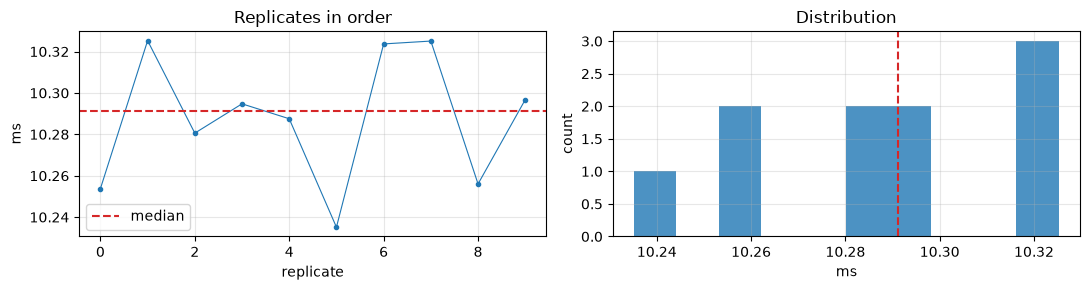

In [13]:
import matplotlib.pyplot as plt

times_ms = [t * 1e3 for t in m.times]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.0))
ax[0].plot(times_ms, ".-", lw=.8)
ax[0].axhline(m.median * 1e3, color="tab:red", ls="--", label="median")
ax[0].set(xlabel="replicate", ylabel="ms", title="Replicates in order")
ax[0].legend()
ax[1].hist(times_ms, bins=min(20, len(times_ms)), color="tab:blue", alpha=.8)
ax[1].axvline(m.median * 1e3, color="tab:red", ls="--")
ax[1].set(xlabel="ms", ylabel="count", title="Distribution")
for a in ax:
    a.grid(alpha=.3)
plt.tight_layout(); plt.show()

A **rising trend** in the left plot means thermal throttling or a warming cache — your
"benchmark" is measuring the machine heating up. A **long right tail** in the histogram
means interference from other processes. Both are reasons to distrust the mean and to
report the median.

### 3.3 Is a difference real? An honest A/B helper

The question that actually matters is never "which median is smaller" but **"is the gap
bigger than the noise?"** Two measurements whose IQR bands overlap have not been shown to
differ, no matter what their medians say.

In [14]:
def ab_compare(a: Measurement, b: Measurement, name_a="A", name_b="B", verbose=True):
    """Compare two Measurements, refusing to call noise a result."""
    qa = (a.median - a.iqr / 2, a.median + a.iqr / 2)
    qb = (b.median - b.iqr / 2, b.median + b.iqr / 2)
    overlap = qa[0] <= qb[1] and qb[0] <= qa[1]
    speedup = a.median / b.median
    noise = max(a.iqr / a.median, b.iqr / b.median)
    effect = abs(speedup - 1)

    if overlap or effect < noise:
        verdict = "NOT SIGNIFICANT - within measurement noise"
    else:
        faster, slower = (name_b, name_a) if speedup > 1 else (name_a, name_b)
        verdict = f"{faster} is {max(speedup, 1/speedup):.2f}x faster than {slower}"

    if verbose:
        print(f"{name_a:<22} {a.median*1e3:8.3f} ms  +/- {a.iqr*1e3:.3f} (IQR)")
        print(f"{name_b:<22} {b.median*1e3:8.3f} ms  +/- {b.iqr*1e3:.3f} (IQR)")
        print(f"{'relative':<22} {speedup:8.3f}x        noise floor ~{100*noise:.1f}%")
        print(f"verdict: {verdict}")
    return {"speedup": speedup, "significant": not (overlap or effect < noise)}


print("--- the null experiment from 1.4, judged properly ---")
ab_compare(run_a, run_b, "run A", "run B")

--- the null experiment from 1.4, judged properly ---
run A                    54.386 ms  +/- 3.658 (IQR)
run B                    53.674 ms  +/- 0.285 (IQR)
relative                  1.013x        noise floor ~6.7%
verdict: NOT SIGNIFICANT - within measurement noise


{'speedup': 1.0132731083991315, 'significant': False}

Run that on two identical benchmarks and it should say **NOT SIGNIFICANT**. If it ever
claims a real difference between two identical runs, your machine is too noisy to
benchmark on right now — close things and try again.

Now the real comparison: the two Mamba scan implementations from the profiler workshop.

In [15]:
def time_model(model, x, threads=None, **kw):
    return Timer(stmt="model(x)", globals={"model": model, "x": x},
                 num_threads=threads or torch.get_num_threads(), **kw
                 ).blocked_autorange(min_run_time=1.0)


with torch.inference_mode():
    m_naive = time_model(mamba_naive, X_SMALL)
    m_fast  = time_model(mamba_fast,  X_SMALL)

ab_compare(m_naive, m_fast, "Mamba S6Naive", "Mamba S6Fast");

Mamba S6Naive            20.728 ms  +/- 0.295 (IQR)
Mamba S6Fast             15.336 ms  +/- 0.195 (IQR)
relative                  1.352x        noise floor ~1.4%
verdict: Mamba S6Fast is 1.35x faster than Mamba S6Naive


---
## Part 4 — `Compare`: benchmark matrices

One measurement at a time does not scale. `Compare` takes a list of `Measurement`s and lays
them out as a table, using three fields you set on each `Timer`:

```
label       ->  the table       ("ResNet-18 forward")
sub_label   ->  the ROW         ("batch 4")
description ->  the COLUMN      ("channels_last")
num_threads ->  a row GROUP     (a separate block of rows per thread count)
```

Get those four right and a nested loop produces a publication-ready table.

### 4.1 A two-dimensional sweep

In [16]:
results = []
for n in [128, 256, 512]:
    a = torch.randn(n, n)
    for desc, stmt in [("a @ a", "a @ a"), ("a.sin()", "a.sin()"),
                       ("a + a", "a + a"), ("a.sum()", "a.sum()")]:
        results.append(
            Timer(stmt=stmt, globals={"a": a},
                  label="Elementwise vs matmul scaling",
                  sub_label=f"{n} x {n}",
                  description=desc,
                  num_threads=1).blocked_autorange(min_run_time=0.1))

c = Compare(results)
c.trim_significant_figures()      # drop digits the data does not support
c.colorize(rowwise=True)          # colour each row relative to its own best
c.print()

[------------- Elementwise vs matmul scaling -------------]
                 |  a @ a  |  a.sin()  |  a + a  |  a.sum()
1 threads: ------------------------------------------------
      128 x 128  |     4   |     18    |     2   |      1  
      256 x 256  |    24   |     71    |     5   |      3  
      512 x 512  |   200   |    281    |    19   |     11  

Times are in microseconds (us).



`trim_significant_figures()` applies §3.1's lesson table-wide. `colorize(rowwise=True)`
shades each row against its own fastest entry, which is what you want when the rows have
different magnitudes.

Read the scaling: from 128 to 512 the tensor grows **16×** in elements. The elementwise ops
grow roughly 16× with it. The matmul grows far more, because its work is O(n³) while its
data is O(n²).

### 4.2 Thread sweep as a row group

Pass different `num_threads` and `Compare` groups the rows automatically.

In [17]:
results = []
with torch.inference_mode():
    for th in [1, 2, 4]:
        for name, model, x in [("ResNet-18", resnet, X_IMG),
                               ("MobileNetV3-Small", mobilenet, X_IMG),
                               ("ViT-Tiny", vit, X_IMG),
                               ("Mamba", mamba_fast, X_SMALL)]:
            results.append(
                Timer(stmt="model(x)", globals={"model": model, "x": x},
                      label="Thread scaling (forward pass)",
                      sub_label=name, description="eager fp32",
                      num_threads=th).blocked_autorange(min_run_time=0.3))

c = Compare(results)
c.trim_significant_figures()
c.print()

[-- Thread scaling (forward pass) ---]
                         |  eager fp32
1 threads: ---------------------------
      ResNet-18          |      54    
      MobileNetV3-Small  |      31    
      ViT-Tiny           |      12    
      Mamba              |       7    
2 threads: ---------------------------
      ResNet-18          |      47    
      MobileNetV3-Small  |      54    
      ViT-Tiny           |      12    
      Mamba              |      11    
4 threads: ---------------------------
      ResNet-18          |      35    
      MobileNetV3-Small  |      90    
      ViT-Tiny           |      10    
      Mamba              |      15    

Times are in milliseconds (ms).



Compare how the four architectures respond to more threads. ResNet-18 usually scales best:
large convolutions decompose cleanly across cores. The Mamba model scales worst, because its
bottleneck is a **sequential Python loop**, and no number of threads fixes a data dependency.

Watch MobileNetV3-Small in the middle. It is convolutional, so you might expect ResNet-like
scaling — but its depthwise layers are split into hundreds of single-channel convolutions
too small to be worth distributing, so much of its time is dispatch rather than arithmetic.
**Thread scaling is a property of the work, not of the model family.**

The profiler workshop diagnosed both bottlenecks; here the benchmark quantifies the
consequence.

---
---
## Part 5 — Benchmarking **inference**

Inference benchmarking asks: **how long does one request take, and how many can I serve?**
Those are two different numbers and they trade against each other.

### 5.1 Latency and throughput across batch sizes

In [18]:
rows, results = [], []
with torch.inference_mode():
    for bs in [1, 2, 4, 8, 16]:
        xb = torch.randn(bs, 3, 224, 224)
        m = Timer(stmt="vit(xb)", globals={"vit": vit, "xb": xb},
                  label="ViT-Tiny batch scaling", sub_label=f"batch {bs:>2}",
                  description="eager fp32",
                  num_threads=torch.get_num_threads()).blocked_autorange(min_run_time=0.5)
        results.append(m)
        rows.append({"batch": bs,
                     "latency_ms": m.median * 1e3,
                     "ms_per_image": m.median * 1e3 / bs,
                     "img_per_s": bs / m.median,
                     "iqr_%": 100 * m.iqr / m.median})

sweep = pd.DataFrame(rows)
display(sweep.round(2))
Compare(results).print()

,batch,latency_ms,ms_per_image,img_per_s,iqr_%
0,1,3.34,3.34,299.31,1.26
1,2,6.02,3.01,332.29,0.69
2,4,10.23,2.56,390.83,1.05
3,8,18.87,2.36,423.92,0.73
4,16,43.88,2.74,364.63,2.46


[-- ViT-Tiny batch scaling -]
                |  eager fp32
4 threads: ------------------
      batch  1  |      3.3   
      batch  2  |      6.0   
      batch  4  |     10.2   
      batch  8  |     18.9   
      batch 16  |     43.9   

Times are in milliseconds (ms).



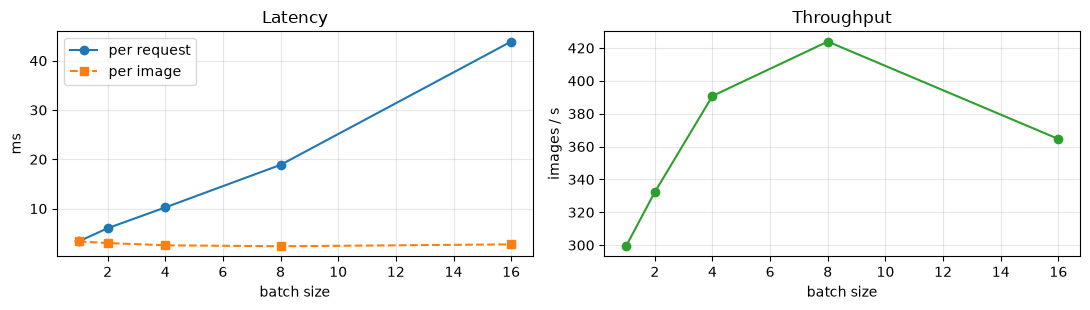

peak throughput at batch 8: 424 img/s, but 18.9 ms per request
lowest latency at batch 1: 3.3 ms, only 299 img/s


In [19]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(sweep.batch, sweep.latency_ms, "o-", label="per request")
ax[0].plot(sweep.batch, sweep.ms_per_image, "s--", label="per image")
ax[0].set(xlabel="batch size", ylabel="ms", title="Latency")
ax[0].legend()
ax[1].plot(sweep.batch, sweep.img_per_s, "o-", color="tab:green")
ax[1].set(xlabel="batch size", ylabel="images / s", title="Throughput")
for a in ax:
    a.grid(alpha=.3)
plt.tight_layout(); plt.show()

best = sweep.loc[sweep.img_per_s.idxmax()]
print(f"peak throughput at batch {int(best.batch)}: {best.img_per_s:.0f} img/s, "
      f"but {best.latency_ms:.1f} ms per request")
print(f"lowest latency at batch {int(sweep.batch.iloc[0])}: {sweep.latency_ms.iloc[0]:.1f} ms, "
      f"only {sweep.img_per_s.iloc[0]:.0f} img/s")

**`ms_per_image` falling while `latency_ms` rises is the whole story of batching.** Which
one you optimise is a product decision, not a technical one: an interactive service is
bounded by the first curve, a nightly batch job by the second.

### 5.2 A four-way model comparison

Note the two input sizes — this is *not* an apples-to-apples architecture comparison, and
the table says so in the row labels. Being explicit about that is part of benchmarking
honestly.

The first two rows *are* directly comparable: ResNet-18 and MobileNetV3-Small run on the
same 224px input. MobileNetV3-Small has 4.6× fewer parameters and does ~32× less arithmetic,
and is the slowest entry in the table.

In [20]:
results = []
with torch.inference_mode():
    for name, model, x in [("ResNet-18  (224px)", resnet, X_IMG),
                           ("MobileNetV3-S (224px)", mobilenet, X_IMG),
                           ("ViT-Tiny   (224px)", vit, X_IMG),
                           ("Mamba S6Naive (64px)", mamba_naive, X_SMALL),
                           ("Mamba S6Fast  (64px)", mamba_fast, X_SMALL)]:
        results.append(
            Timer(stmt="model(x)", globals={"model": model, "x": x},
                  label="Forward pass, batch 4", sub_label=name,
                  description="eager fp32",
                  num_threads=torch.get_num_threads()).blocked_autorange(min_run_time=0.8))

c = Compare(results); c.trim_significant_figures(); c.colorize(); c.print()

summary = pd.DataFrame([
    {"model": m.task_spec.sub_label,
     "median_ms": m.median * 1e3,
     "iqr_%": 100 * m.iqr / m.median,
     "sig_figs": m.significant_figures}
    for m in results])
display(summary.round(2))

[-------- Forward pass, batch 4 ---------]
                             |  eager fp32
4 threads: -------------------------------
      ResNet-18  (224px)     |      35    
      MobileNetV3-S (224px)  |      90    
      ViT-Tiny   (224px)     |      11    
      Mamba S6Naive (64px)   |      20    
      Mamba S6Fast  (64px)   |      15    

Times are in milliseconds (ms).



,model,median_ms,iqr_%,sig_figs
0,ResNet-18 (224px),35.28,1.89,2
1,MobileNetV3-S (224px),89.67,0.60,2
2,ViT-Tiny (224px),10.55,1.29,3
3,Mamba S6Naive (64px),20.20,2.55,2
4,Mamba S6Fast (64px),15.10,2.74,2


### 5.3 `no_grad` vs `inference_mode` vs nothing

A benchmark that settles a question people argue about. All three produce identical outputs
for inference; only the bookkeeping differs.

In [21]:
import contextlib

ctxs = {"grad enabled": contextlib.nullcontext,
        "torch.no_grad": torch.no_grad,
        "torch.inference_mode": torch.inference_mode}


def interleaved(variants, repeats=3, min_run_time=0.6):
    """Measure each variant `repeats` times, ROUND-ROBIN, and take the median of medians.

    Running A three times then B three times bakes in any drift that happened between the
    two groups. Round-robin spreads that drift evenly across all variants instead.
    """
    acc = {name: [] for name in variants}
    for _ in range(repeats):
        for name, (ctx, model, x) in variants.items():
            with ctx():
                m = Timer(stmt="model(x)", globals={"model": model, "x": x},
                          num_threads=torch.get_num_threads()
                          ).blocked_autorange(min_run_time=min_run_time)
            acc[name].append(m.median * 1e3)
    return {k: statistics.median(v) for k, v in acc.items()}


rows = []
for mdl_name, model, x in [("ResNet-18", resnet, X_IMG), ("Mamba S6Fast", mamba_fast, X_SMALL)]:
    res = interleaved({name: (ctx, model, x) for name, ctx in ctxs.items()})
    base = res["grad enabled"]
    rows.append({"model": mdl_name,
                 **{k: v for k, v in res.items()},
                 "no_grad vs grad": f"{100*(res['torch.no_grad']/base - 1):+.1f}%",
                 "inference_mode vs grad": f"{100*(res['torch.inference_mode']/base - 1):+.1f}%"})

display(pd.DataFrame(rows).round(2))

,model,grad enabled,torch.no_grad,torch.inference_mode,no_grad vs grad,inference_mode vs grad
0,ResNet-18,35.40,35.28,35.25,-0.3%,-0.4%
1,Mamba S6Fast,17.26,15.57,15.07,-9.8%,-12.7%


Two results, and the contrast is the point:

* **ResNet-18: the difference is roughly zero** — well inside the noise floor. Each of its
  ~20 convolutions does so much arithmetic that the autograd bookkeeping around it does not
  register.
* **Mamba: a clear ~10% for `no_grad` and a bit more for `inference_mode`** — because it
  pays that same per-op bookkeeping *hundreds* of times per forward pass.

**Per-op overheads hurt op-heavy models most.** Same principle that made the `S6Fast`
rewrite pay off, measured from the other direction.

> ### Note the methodology, not just the result
> The first draft of this cell measured all three contexts for one model, then moved on to
> the next — and produced *nonsense*, with `grad enabled` apparently beating
> `inference_mode`. The differences here are a few percent, which is smaller than the
> machine's drift over the tens of seconds the cell takes to run.
>
> `interleaved()` fixes it by cycling A → B → C → A → B → C and taking the median of each
> variant's replicates. **Whenever your effect size is close to your noise floor,
> interleave.** Measuring A fully and then B fully attributes every drift in between to B.

### 5.4 CPU vs MPS

`Timer` synchronises the accelerator for you (§1.3), so a mixed-device table is safe to
write. Both devices appear in one `Compare`.

In [22]:
if torch.backends.mps.is_available():
    results = []
    with torch.inference_mode():
        for dev in ["cpu", "mps"]:
            for name, model, x in [("ResNet-18", resnet, X_IMG),
                                   ("MobileNetV3-Small", mobilenet, X_IMG),
                                   ("ViT-Tiny", vit, X_IMG),
                                   ("Mamba S6Fast", mamba_fast, X_SMALL)]:
                md_ = model.to(dev)
                xd = x.to(dev)
                md_(xd)                                    # warmup: compiles Metal pipelines
                if dev == "mps":
                    torch.mps.synchronize()
                results.append(
                    Timer(stmt="m(x)", globals={"m": md_, "x": xd},
                          label="CPU vs MPS (batch 4)", sub_label=name,
                          description=dev,
                          # give the CPU its full thread budget, or the comparison is rigged
                          num_threads=torch.get_num_threads()
                          ).blocked_autorange(min_run_time=0.5))
                model.to("cpu")

    c = Compare(results); c.trim_significant_figures(); c.colorize(rowwise=True); c.print()
    print("Reminder: these MPS numbers are only trustworthy because Timer synchronises.")
else:
    print("No MPS on this machine - skipping.")

[-------- CPU vs MPS (batch 4) -------]
                         |  cpu  |  mps
4 threads: ----------------------------
      ResNet-18          |   35  |   11
      MobileNetV3-Small  |   90  |    7
      ViT-Tiny           |   11  |    5
      Mamba S6Fast       |   15  |   16

Times are in milliseconds (ms).

Reminder: these MPS numbers are only trustworthy because Timer synchronises.


Expect the GPU to win comfortably on the convolutional and transformer models, and to win
by much less — possibly to *lose* — on the Mamba model. A sequential Python loop issuing
tiny kernels keeps the GPU idle between launches; moving that workload to a faster device
does not fix a launch-bound problem.

**MobileNetV3-Small usually shows the largest speedup of all**, often an order of magnitude.
That is the other half of its story: the depthwise convolutions that have no fast CPU path
are exactly what the GPU is good at. The model is not slow — *the CPU is the wrong hardware
for it*, which is unsurprising for an architecture designed for mobile accelerators.

**A device is not an optimisation. It is a different set of trade-offs, and which model
wins depends on which trade-offs it happens to need.**

### 5.5 Guarding a benchmark: catching a regression

The practical end product of benchmarking is usually not a table, it is a **gate**: a check
that fails when someone makes the model slower. `adaptive_autorange` is the right tool,
because it keeps sampling until the result is stable rather than for a fixed time.

In [23]:
def assert_not_slower(fn_new, fn_ref, tolerance=0.10, min_run_time=0.2, label=""):
    """Fail if fn_new is more than `tolerance` slower than fn_ref, beyond noise."""
    a = Timer(stmt="f()", globals={"f": fn_ref}).adaptive_autorange(
        threshold=0.05, min_run_time=min_run_time, max_run_time=5.0)
    b = Timer(stmt="f()", globals={"f": fn_new}).adaptive_autorange(
        threshold=0.05, min_run_time=min_run_time, max_run_time=5.0)
    ratio = b.median / a.median
    noise = max(a.iqr / a.median, b.iqr / b.median)
    ok = ratio <= 1 + max(tolerance, noise)
    print(f"{label:<28} reference {a.median*1e3:7.2f} ms | candidate {b.median*1e3:7.2f} ms "
          f"| {ratio:5.2f}x | noise {100*noise:4.1f}% | {'PASS' if ok else 'FAIL'}")
    return ok


with torch.inference_mode():
    assert_not_slower(lambda: mamba_fast(X_SMALL), lambda: mamba_naive(X_SMALL),
                      label="S6Fast vs S6Naive")
    assert_not_slower(lambda: mamba_naive(X_SMALL), lambda: mamba_fast(X_SMALL),
                      label="S6Naive vs S6Fast (should FAIL)")

S6Fast vs S6Naive            reference    7.07 ms | candidate    6.42 ms |  0.91x | noise  0.6% | PASS


S6Naive vs S6Fast (should FAIL) reference    6.44 ms | candidate    7.06 ms |  1.10x | noise  0.7% | PASS


The second call is expected to fail — it asks whether the slower implementation is an
acceptable replacement for the faster one, and it is not. **A regression gate you have
never seen fail is a regression gate you should not trust.**

Note the `max(tolerance, noise)` term: the gate automatically loosens on a noisy machine
rather than producing false alarms. That is the difference between a check people keep and
one they disable.

---
---
## Part 6 — Benchmarking **training**

Training benchmarking asks a different question: **seconds per step**, and therefore hours
per epoch. Three things change:

1. **Gradients must be enabled.** `inference_mode` here is a bug, not an optimisation.
2. **There is state.** Each step mutates weights and optimiser buffers, so replicates are
   not independent the way inference replicates are. Adam's first step allocates its moment
   buffers — warm up before measuring.
3. **`stmt` gets longer.** A step is zero-grad, forward, loss, backward, step.

`Timer` handles multi-line `stmt` strings directly, which keeps the benchmark readable.

### 6.1 A full training step

In [24]:
def make_trainable(model_fn, x, lr=1e-3, opt_cls=torch.optim.AdamW):
    model = model_fn()
    model.train()
    opt = opt_cls(model.parameters(), lr=lr)
    y = torch.randint(0, 10, (x.size(0),))
    return model, opt, x, y


criterion = nn.CrossEntropyLoss()

STEP_STMT = """
opt.zero_grad(set_to_none=True)
loss = criterion(model(x), y)
loss.backward()
opt.step()
"""

model, opt, x, y = make_trainable(
    lambda: torchvision.models.resnet18(num_classes=10, weights=None), torch.randn(8, 3, 224, 224))

g = {"model": model, "opt": opt, "x": x, "y": y, "criterion": criterion}

# warmup OUTSIDE the timer: the first AdamW step allocates exp_avg / exp_avg_sq buffers
for _ in range(3):
    exec(STEP_STMT, g)

m_step = Timer(stmt=STEP_STMT, globals=g, label="ResNet-18 training",
               sub_label="batch 8", description="full step (AdamW)",
               num_threads=torch.get_num_threads()).blocked_autorange(min_run_time=2.0)
print(m_step)

ResNet-18 training: batch 8
full step (AdamW)
  Median: 197.46 ms
  IQR:    1.15 ms (197.02 to 198.17)
  11 measurements, 1 runs per measurement, 4 threads


### 6.2 Where does a step go? forward / backward / optimiser

Benchmarking nested prefixes and subtracting gives you the split without a profiler. It is
cruder than §3 of the profiler workshop, but it needs no instrumentation and it measures
**real** time rather than instrumented time.

In [25]:
# Loss is folded into "forward": CrossEntropyLoss on (8, 10) costs microseconds, far below
# the noise floor, so isolating it would only produce a meaningless (possibly negative) row.
stages = {
    "1. forward + loss": "loss = criterion(model(x), y)",
    "2. + backward":     "opt.zero_grad(set_to_none=True)\n"
                         "loss = criterion(model(x), y)\nloss.backward()",
    "3. + optimiser (full step)": STEP_STMT,
}

results = []
for name, stmt in stages.items():
    results.append(Timer(stmt=stmt, globals=g, label="ResNet-18 training step, cumulative",
                         sub_label="batch 8", description=name,
                         num_threads=torch.get_num_threads()
                         ).blocked_autorange(min_run_time=1.5))

c = Compare(results); c.trim_significant_figures(); c.print()

med = [r.median * 1e3 for r in results]
split = pd.DataFrame([
    {"stage": "forward + loss", "ms": med[0]},
    {"stage": "backward",       "ms": med[1] - med[0]},
    {"stage": "optimiser",      "ms": med[2] - med[1]},
])
split["share_%"] = 100 * split.ms / split.ms.sum()
display(split.round(2))
print(f"backward / forward = {split.ms[1]/split.ms[0]:.2f}x")
if (split.ms < 0).any():
    print("NEGATIVE STAGE -> the differences are inside the noise floor; "
          "use the profiler's record_function labels instead.")

[---------------------- ResNet-18 training step, cumulative -----------------------]
               |  1. forward + loss  |  2. + backward  |  3. + optimiser (full step)
4 threads: -------------------------------------------------------------------------
      batch 8  |          80         |       200       |             200            

Times are in milliseconds (ms).



,stage,ms,share_%
0,forward + loss,79.89,40.37
1,backward,105.54,53.33
2,optimiser,12.47,6.30


backward / forward = 1.32x


**Expect backward to cost somewhere between 1× and 2× the forward pass.** The textbook
argument for 2× is that autograd computes a gradient with respect to the input *and* one
with respect to the weights, roughly two matmuls where forward did one. Reality lands lower
whenever the forward pass is doing work that backward does not repeat — and on this machine
the convolution backward kernels are relatively well optimised.

**Read your own ratio rather than quoting the rule of thumb.** If yours is far above 2,
something in your backward is pathological and the profiler will find it.

> Cumulative subtraction is not free of sin — each row re-runs the forward pass, so noise
> accumulates and a negative "stage" is possible on a noisy machine. If a stage comes out
> negative, that is your signal that the differences are inside the noise floor and you
> should use the profiler's `record_function` labels instead.

### 6.3 Optimiser choice

In [26]:
results = []
for opt_name, opt_cls in [("SGD", torch.optim.SGD),
                          ("SGD+momentum", lambda p, lr: torch.optim.SGD(p, lr=lr, momentum=0.9)),
                          ("Adam", torch.optim.Adam),
                          ("AdamW", torch.optim.AdamW)]:
    mdl, o, xx, yy = make_trainable(
        lambda: torchvision.models.resnet18(num_classes=10, weights=None),
        torch.randn(8, 3, 224, 224), opt_cls=opt_cls)
    gg = {"model": mdl, "opt": o, "x": xx, "y": yy, "criterion": criterion}
    for _ in range(3):
        exec(STEP_STMT, gg)
    results.append(Timer(stmt=STEP_STMT, globals=gg, label="Optimiser cost (ResNet-18, batch 8)",
                         sub_label="full training step", description=opt_name,
                         num_threads=torch.get_num_threads()).blocked_autorange(min_run_time=1.0))

    # isolate just opt.step()
    results.append(Timer(stmt="opt.step()", globals=gg,
                         label="Optimiser cost (ResNet-18, batch 8)",
                         sub_label="opt.step() alone", description=opt_name,
                         num_threads=torch.get_num_threads()).blocked_autorange(min_run_time=0.5))

c = Compare(results); c.trim_significant_figures(); c.colorize(rowwise=True); c.print()

[-------------- Optimiser cost (ResNet-18, batch 8) ---------------]
                          |  SGD  |  SGD+momentum  |  Adam  |  AdamW
4 threads: ---------------------------------------------------------
      full training step  |  190  |      190       |  200   |   200 
      opt.step() alone    |    2  |        4       |   10   |    11 

Times are in milliseconds (ms).



Read the second row: `opt.step()` in isolation. Adam and AdamW maintain two extra buffers
per parameter and touch all of them every step, so they cost several times what plain SGD
does. Read the first row: as a **share of the whole step** that difference is small, because
backward dominates.

**Both readings are true, and reporting only one of them is how benchmarks mislead.**
Optimiser choice matters for memory (2 extra copies of every parameter) far more than for
step time.

### 6.4 `set_to_none=True` — a benchmark that reframes the question

In [27]:
# Measure inside a REAL step. Timing `zero_grad` alone is a trap: with set_to_none=True the
# first call sets every .grad to None, so every later call in the same timing loop has
# nothing left to do and the benchmark measures an empty function.
STEP_FLAG = ("opt.zero_grad(set_to_none=flag)\n"
             "loss = criterion(model(x), y)\nloss.backward()\nopt.step()")

results, mem_rows = [], []
for desc, flag in [("set_to_none=True (default)", True), ("set_to_none=False", False)]:
    mdl = torchvision.models.resnet18(num_classes=10, weights=None)
    mdl.train()
    o = torch.optim.SGD(mdl.parameters(), lr=1e-3)
    gg = {"model": mdl, "opt": o, "x": torch.randn(8, 3, 64, 64),
          "y": torch.randint(0, 10, (8,)), "criterion": criterion, "flag": flag}
    for _ in range(3):
        exec(STEP_FLAG, gg)

    results.append(Timer(stmt=STEP_FLAG, globals=gg, label="zero_grad strategies",
                         sub_label="full training step", description=desc,
                         num_threads=torch.get_num_threads()).blocked_autorange(min_run_time=1.5))

    o.zero_grad(set_to_none=flag)              # the state a step leaves behind
    held = sum(p.grad.numel() * p.grad.element_size()
               for p in mdl.parameters() if p.grad is not None)
    mem_rows.append({"setting": desc,
                     "grad tensors allocated": sum(1 for p in mdl.parameters() if p.grad is not None),
                     "memory held (MB)": held / 2**20})

c = Compare(results); c.trim_significant_figures(); c.colorize(rowwise=True); c.print()
display(pd.DataFrame(mem_rows).round(2))
ab_compare(results[0], results[1], "set_to_none=True", "set_to_none=False");

[--------------------------- zero_grad strategies --------------------------]
                          |  set_to_none=True (default)  |  set_to_none=False
4 threads: ------------------------------------------------------------------
      full training step  |              35              |         37.2      

Times are in milliseconds (ms).



,setting,grad tensors allocated,memory held (MB)
0,set_to_none=True (default),0,0.00
1,set_to_none=False,62,42.65


set_to_none=True         35.403 ms  +/- 2.726 (IQR)
set_to_none=False        37.212 ms  +/- 0.310 (IQR)
relative                  0.951x        noise floor ~7.7%
verdict: NOT SIGNIFICANT - within measurement noise


#### The benchmark says: stop arguing about the time

The **time** difference is a few percent — real, but small, and on a noisier machine it
would disappear entirely. Zeroing ~11 M floats is memory-bandwidth work that is trivial next
to a backward pass, so the usual folklore ("`set_to_none=True` is faster") is technically
true and practically irrelevant.

The **memory** table is where the real difference lives: `set_to_none=False` keeps a full
gradient tensor allocated for every parameter — a second complete copy of the model, held
for the whole run. `set_to_none=True` releases them.

> **This is what benchmarking is for.** Not to confirm folklore, but to discover that the
> advice is right for the wrong reason. Had we only timed it, we would have concluded the
> setting does not matter. Had we only repeated the docs, we would have called it a speed
> optimisation. It is a *memory* optimisation.

(One behavioural difference to know: with `set_to_none=True`, `p.grad` is `None` rather
than a zero tensor between steps. Code that reads `p.grad` unconditionally — gradient
clipping, logging, custom optimisers — must handle `None`.)

### 6.5 Batch size and the cost of an epoch

The number a researcher actually wants is **minutes per epoch**, which a per-step benchmark
gives you once you know the dataset size.

In [28]:
DATASET_SIZE = 50_000                      # pretend CIFAR-scale

# One model reused across batch sizes; a fresh ResNet per row would add allocator noise
mdl = torchvision.models.resnet18(num_classes=10, weights=None)
mdl.train()
o = torch.optim.AdamW(mdl.parameters(), lr=1e-3)

rows = []
for bs in [4, 8, 16, 32]:
    gg = {"model": mdl, "opt": o, "x": torch.randn(bs, 3, 64, 64),
          "y": torch.randint(0, 10, (bs,)), "criterion": criterion}
    for _ in range(3):
        exec(STEP_STMT, gg)
    m = Timer(stmt=STEP_STMT, globals=gg,
              num_threads=torch.get_num_threads()).blocked_autorange(min_run_time=1.5)
    steps = math.ceil(DATASET_SIZE / bs)
    rows.append({"batch": bs, "step_ms": m.median * 1e3,
                 "iqr_%": 100 * m.iqr / m.median,
                 "ms_per_sample": m.median * 1e3 / bs,
                 "steps_per_epoch": steps,
                 "epoch_min": steps * m.median / 60})

ep = pd.DataFrame(rows)
display(ep.round(2))

best, worst = ep.loc[ep.epoch_min.idxmin()], ep.loc[ep.epoch_min.idxmax()]
print(f"For a {DATASET_SIZE:,}-sample epoch on THIS machine:")
print(f"  best  : batch {int(best.batch):>2} -> {best.epoch_min:5.1f} min")
print(f"  worst : batch {int(worst.batch):>2} -> {worst.epoch_min:5.1f} min "
      f"({worst.epoch_min/best.epoch_min:.2f}x longer)")

,batch,step_ms,iqr_%,ms_per_sample,steps_per_epoch,epoch_min
0,4,28.18,2.19,7.05,12500,5.87
1,8,44.70,1.19,5.59,6250,4.66
2,16,141.80,1.76,8.86,3125,7.39
3,32,239.58,0.85,7.49,1563,6.24


For a 50,000-sample epoch on THIS machine:
  best  : batch  8 ->   4.7 min
  worst : batch 16 ->   7.4 min (1.59x longer)


**Look at `ms_per_sample` before anything else.** If scaling were smooth it would fall
monotonically as the batch grows, since fixed per-step overheads get amortised over more
samples.

On this machine it does not. It typically dips and then jumps back up at some batch size.
That is a real effect, not noise — the `iqr_%` column shows these measurements are stable.
Somewhere in that range a working set stops fitting in cache, or the thread partitioning
changes, and per-sample cost gets worse.

> **You cannot interpolate a benchmark.** "Batch 8 took 50 ms, so batch 16 will take 100 ms"
> is a guess, and here it is wrong. Benchmark the batch size you intend to run, on the
> machine you intend to run it on.

With that caveat, this is exactly the table to put in front of someone deciding whether a
training run is feasible — and it took a minute to produce, versus hours to find out by
launching the job and waiting.

Be honest about what it still ignores: data loading (profiler workshop §3.4), validation
passes, checkpointing, and the fact that a larger batch may need more epochs to reach the
same accuracy. **Wall-clock per epoch is not time-to-a-good-model.**

---
## Part 7 — Advanced tools

### 7.1 `Fuzzer` — benchmark the shapes you did not think of

Hand-picked benchmark shapes are usually powers of two, contiguous, and nicely aligned —
in other words, the best case. Real tensors are none of those things. `Fuzzer` generates
randomised but *reproducible* inputs so you sample the space you actually run in.

Three pieces:

* **`FuzzedParameter`** — a scalar drawn from a distribution (`uniform`, `loguniform`, or
  explicit weights).
* **`FuzzedTensor`** — a tensor whose `size` refers to those parameters by name, with
  constraints such as `min_elements`, `max_elements` and `probability_contiguous`.
* **`ParameterAlias`** — makes one parameter reuse another, for when dimensions must match.

In [29]:
from torch.utils.benchmark import Fuzzer, FuzzedParameter, FuzzedTensor, ParameterAlias

fuzzer = Fuzzer(
    parameters=[
        FuzzedParameter("k0", minval=16, maxval=2048, distribution="loguniform"),
        FuzzedParameter("k1", minval=16, maxval=2048, distribution="loguniform"),
    ],
    tensors=[
        FuzzedTensor("x", size=("k0", "k1"),
                     min_elements=4096, max_elements=512_000,
                     probability_contiguous=0.5),
    ],
    seed=42,
)

rows = []
for tensors, tensor_params, params in fuzzer.take(12):
    x = tensors["x"]
    m = Timer(stmt="x.sum(dim=0)", globals={"x": x},
              num_threads=1).blocked_autorange(min_run_time=0.05)
    rows.append({"shape": str(tuple(x.shape)),
                 "elements": x.numel(),
                 "contiguous": x.is_contiguous(),
                 "us": m.median * 1e6,
                 "ns_per_element": m.median * 1e9 / x.numel()})

fz = pd.DataFrame(rows).sort_values("ns_per_element", ascending=False, ignore_index=True)
display(fz.round(3))

,shape,elements,contiguous,us,ns_per_element
0,"(20, 305)",6100,True,1.097,0.180
1,"(17, 1769)",30073,False,5.296,0.176
2,"(21, 1069)",22449,False,3.949,0.176
3,"(21, 1598)",33558,False,5.220,0.156
4,"(292, 34)",9928,True,1.243,0.125
5,"(43, 251)",10793,True,1.225,0.113
6,"(51, 440)",22440,False,2.504,0.112
7,"(1803, 49)",88347,True,9.294,0.105
8,"(952, 141)",134232,True,10.457,0.078
9,"(321, 102)",32742,False,2.321,0.071


In [30]:
by_layout = fz.groupby("contiguous").ns_per_element.median()
display(by_layout.round(3).rename("median ns/element"))
if len(by_layout) == 2:
    print(f"\nnon-contiguous tensors cost {by_layout[False]/by_layout[True]:.1f}x more "
          f"per element than contiguous ones")
print("\nA hand-written benchmark using only torch.randn() would never have found this,")
print("because torch.randn() is always contiguous.")

contiguous
False    0.156
True     0.105
Name: median ns/element, dtype: float64


non-contiguous tensors cost 1.5x more per element than contiguous ones

A hand-written benchmark using only torch.randn() would never have found this,
because torch.randn() is always contiguous.


Notice the `ns_per_element` column rather than raw time: it normalises away tensor size so
the *layout* effect is visible. Choosing the right normalisation is most of the skill in
reading a fuzzed benchmark.

### 7.2 C++ timing — measuring Python's overhead directly

`Timer(language="c++")` compiles your snippet against libtorch and times it with no Python
interpreter in the loop. Subtracting the two gives you **the per-call cost of Python
itself** — the exact quantity that makes op-heavy models like our Mamba slow.

Requirements: a C++ toolchain and `ninja` (`pip install ninja`). On a machine with an
accelerator you must also pass `timer=timeit.default_timer`, because the C++ timer cannot
synchronise the device — which makes it **CPU-only**.

> First run compiles an extension: expect **5–20 seconds**. Set `RUN_CPP = False` to skip.

In [31]:
RUN_CPP = True

if RUN_CPP:
    try:
        t0 = time.perf_counter()
        cpp = Timer(stmt="auto y = x + x;",
                    setup="torch::Tensor x = torch::ones({64});",
                    language="c++",
                    timer=timeit.default_timer,          # required when an accelerator exists
                    num_threads=1).blocked_autorange(min_run_time=0.2)
        py = Timer(stmt="y = x + x",
                   setup="import torch; x = torch.ones(64)",
                   num_threads=1).blocked_autorange(min_run_time=0.2)

        print(f"C++     : {cpp.median*1e9:7.0f} ns per call")
        print(f"Python  : {py.median*1e9:7.0f} ns per call")
        print(f"overhead: {(py.median-cpp.median)*1e9:7.0f} ns per op, "
              f"{py.median/cpp.median:.2f}x")
        print(f"\n(compiled and ran in {time.perf_counter()-t0:.1f}s)")
    except Exception as e:
        print(f"C++ timing unavailable: {type(e).__name__}: {str(e)[:200]}")
        print("Needs a C++ toolchain and `pip install ninja`.")
else:
    print("skipped - set RUN_CPP = True")

C++     :     257 ns per call
Python  :     428 ns per call
overhead:     171 ns per op, 1.66x

(compiled and ran in 7.8s)


Put that number next to the profiler workshop's finding that the naive Mamba scan issues
~27,000 operator calls per forward pass. **Multiply the two and you have most of the
model's runtime, before any arithmetic happens.**

That is the quantitative form of "overhead-bound", and it tells you the ceiling on what
fusing ops can win you.

### 7.3 `collect_callgrind` — counting instructions instead of nanoseconds

Wall-clock time is noisy. Instruction counts are **deterministic**: run it twice, get the
same number. That makes Callgrind the right tool for detecting a 1% regression that would
drown in timing noise, which is exactly what PyTorch's own CI uses it for.

```python
stats = Timer(stmt="x + y", globals={"x": x, "y": y}).collect_callgrind(number=100)
print(stats)                      # total instruction count
print(stats.counts(denoise=True)) # excluding Python interpreter noise
delta = stats_after.delta(stats_before)   # a FunctionCounts diff, per C++ function
```

**Requires Valgrind, which is Linux-only** (it is not supported on macOS at all, and on
Apple Silicon there is no path to it). The cell below detects that and explains rather than
failing.

In [32]:
try:
    a = torch.ones(64)
    stats = Timer(stmt="y = a + a", globals={"a": a}).collect_callgrind(number=50)
    print(stats)
except Exception as e:
    print(f"Callgrind unavailable here: {type(e).__name__}: {e}")
    print()
    print("This is expected on macOS. On Linux, `apt install valgrind` enables:")
    print("  - deterministic instruction counts (re-runnable, CI-friendly)")
    print("  - per-C++-function attribution via FunctionCounts")
    print("  - stats_a.delta(stats_b) to see exactly which functions a change moved")

Callgrind unavailable here: OSError: Valgrind is not supported on this platform.

This is expected on macOS. On Linux, `apt install valgrind` enables:
  - deterministic instruction counts (re-runnable, CI-friendly)
  - per-C++-function attribution via FunctionCounts
  - stats_a.delta(stats_b) to see exactly which functions a change moved


The trade-off: Callgrind runs your code under emulation, roughly **50–100× slower**, and
instruction count is not time — it ignores cache misses, branch prediction and memory
bandwidth. A change can cut instructions and still be slower. Use it to *detect* change
precisely, then confirm with wall-clock timing.

| Tool | Measures | Noise | Speed | Best for |
|---|---|---|---|---|
| `Timer` | wall-clock time | machine-dependent | fast | what users experience |
| `collect_callgrind` | instructions retired | none | very slow | CI regression gates |
| `torch.profiler` | per-op time + memory | instrumented | medium | finding the bottleneck |

### 7.4 From a benchmark result to a trace diff

This is where the two notebooks meet.

Part 3 established, with error bars, that `S6Fast` beats `S6Naive` by about 1.35×. That is
a *number*. It does not say which operators changed — and without that you are guessing
about why your optimisation worked, which means you cannot repeat it.

**The division of labour:**

| Question | Tool |
|---|---|
| Is B faster than A, beyond noise? | `benchmark.Timer` + `ab_compare` |
| By how much, across shapes/threads/devices? | `benchmark.Compare` |
| **Which operators changed?** | **profiler trace + HTA `TraceDiff`** |
| What did the timeline look like? | Perfetto |

`ws_trace.capture_trace()` writes traces the way HTA needs them — profiled with a
`schedule` and written by `tensorboard_trace_handler`, so they carry `ProfilerStep#N`
markers. A plain `export_chrome_trace()` does not, and HTA cannot parse the result.

In [33]:
sys.path.insert(0, str(Path.cwd()))
from ws_trace import (capture_trace, chrome_trace_ops, hta_available,
                      quiet_hta, HTA_ON_CPU)

OUT = Path("benchmark_out"); OUT.mkdir(exist_ok=True)
TRACES = OUT / "traces"

# active=1: one profiled step is plenty for a structural diff, and it keeps the files small.
# An op-heavy model produces an ENORMOUS trace - ~27,000 events per forward pass here, so
# the default active=3 would give us ~30 MB per file.
with torch.inference_mode():
    naive_dir, naive_file = capture_trace(lambda: mamba_naive(X_SMALL), TRACES, "s6_naive",
                                          warmup=1, active=1)
    fast_dir,  fast_file  = capture_trace(lambda: mamba_fast(X_SMALL),  TRACES, "s6_fast",
                                          warmup=1, active=1)

print(f"S6Naive trace: {naive_file.name}  ({naive_file.stat().st_size/1e6:.2f} MB)")
print(f"S6Fast  trace: {fast_file.name}  ({fast_file.stat().st_size/1e6:.2f} MB)")
print(f"\nBenchmark verdict from Part 3: S6Fast was "
      f"{m_naive.median/m_fast.median:.2f}x faster. Now let us see *what* changed.")

USDT:2026-09-26 16:57:34 44589:1727263 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-26 16:57:34 44589:1727263 SyncActivityProfilerHandler.cpp:46] profiler_stop
USDT:2026-09-26 16:57:34 44589:1727263 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-26 16:57:34 44589:1727263 SyncActivityProfilerHandler.cpp:46] profiler_stop


USDT:2026-09-26 16:57:34 44589:1727263 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-26 16:57:35 44589:1727263 SyncActivityProfilerHandler.cpp:46] profiler_stop
USDT:2026-09-26 16:57:35 44589:1727263 SyncActivityProfilerHandler.cpp:39] profiler_start
USDT:2026-09-26 16:57:35 44589:1727263 SyncActivityProfilerHandler.cpp:46] profiler_stop


S6Naive trace: phix-m3.local_44589.1790416654762256000.pt.trace.json  (10.04 MB)
S6Fast  trace: phix-m3.local_44589.1790416655067683000.pt.trace.json  (9.12 MB)

Benchmark verdict from Part 3: S6Fast was 1.35x faster. Now let us see *what* changed.


#### The simple answer first — no HTA required

A Chrome Trace is just JSON. `chrome_trace_ops()` parses it with `pandas` and reconstructs
self time by subtracting each child's duration from its parent. Joining two of those tables
gives you a perfectly serviceable op diff with zero extra dependencies.

In [34]:
a = chrome_trace_ops(naive_file, top=200).set_index("name")[["calls", "self_ms"]]
b = chrome_trace_ops(fast_file,  top=200).set_index("name")[["calls", "self_ms"]]

joined = a.join(b, how="outer", lsuffix="_naive", rsuffix="_fast").fillna(0)
joined["d_calls"] = joined.calls_fast - joined.calls_naive
joined["d_ms"] = joined.self_ms_fast - joined.self_ms_naive

print("ops that got CHEAPER:")
display(joined.nsmallest(6, "d_ms").round(2))
print("ops that got more EXPENSIVE:")
display(joined.nlargest(4, "d_ms").round(2))

ops that got CHEAPER:


,calls_naive,self_ms_naive,calls_fast,self_ms_fast,d_calls,d_ms
name,,,,,,
aten::exp,260.0,3.07,8,0.35,-252.0,-2.72
aten::mul,1032.0,1.63,276,0.78,-756.0,-0.85
aten::unsqueeze,1288.0,0.62,280,0.09,-1008.0,-0.52
aten::_slow_conv2d_forward,385.0,7.56,385,7.11,0.0,-0.45
aten::matmul,264.0,0.46,8,0.02,-256.0,-0.45
aten::select,4352.0,1.56,3888,1.13,-464.0,-0.43


ops that got more EXPENSIVE:


,calls_naive,self_ms_naive,calls_fast,self_ms_fast,d_calls,d_ms
name,,,,,,
aten::einsum,0.0,0.00,256,0.79,256.0,0.79
aten::permute,0.0,0.00,1280,0.51,1280.0,0.51
aten::native_layer_norm,5.0,0.09,5,0.12,0.0,0.03
aten::clone,397.0,0.20,393,0.21,-4.0,0.00


#### The same question through HTA

`TraceDiff` gives you the structural answer directly, categorised into added / deleted /
increased / decreased / unchanged.

In [35]:
if not hta_available():
    print("HolisticTraceAnalysis not installed - run: pip install HolisticTraceAnalysis")
else:
    quiet_hta()        # HTA logs every file it parses, at WARNING level
    from hta.trace_analysis import TraceAnalysis
    from hta.trace_diff import TraceDiff

    ta_naive = TraceAnalysis(trace_dir=str(naive_dir))
    ta_fast  = TraceAnalysis(trace_dir=str(fast_dir))

    changed = TraceDiff.ops_diff(ta_naive.t, ta_fast.t)
    for kind, items in changed.items():
        if len(items):
            print(f"{kind:<12} ({len(items):>3}): {', '.join(list(items)[:6])}")

added        (  2): aten::einsum, aten::permute
increased    (  5): aten::_reshape_alias, aten::bmm, aten::reshape, aten::resolve_conj, aten::view
decreased    ( 14): aten::_unsafe_view, aten::as_strided, aten::clone, aten::copy_, aten::empty, aten::empty_like
unchanged    ( 38): ProfilerStep#1, aten::_convolution, aten::_nnpack_available, aten::_slow_conv2d_forward, aten::_to_copy, aten::add


In [36]:
if hta_available():
    d = TraceDiff.compare_traces(ta_naive.t, ta_fast.t, use_short_name=True)
    d = d.rename(columns={"Control_counts": "naive_calls", "Test_counts": "fast_calls",
                          "Control_total_duration": "naive_us", "Test_total_duration": "fast_us"})
    moved = d[d.diff_counts != 0].sort_values("diff_counts")
    print("operators whose CALL COUNT changed:")
    # Showing counts only, on purpose. HTA's duration columns here are a self-time
    # approximation over a deeply nested CPU trace and can even come out negative -
    # they are not a number to quote. The counts are exact.
    display(moved[["naive_calls", "fast_calls", "diff_counts"]].astype(int).head(10))

operators whose CALL COUNT changed:


,naive_calls,fast_calls,diff_counts
short_name,,,
aten::unsqueeze,1288,280,-1008
aten::as_strided,7624,6672,-952
aten::mul,1032,276,-756
aten::expand,521,17,-504
aten::select,4352,3888,-464
aten::_unsafe_view,268,8,-260
aten::matmul,264,8,-256
aten::squeeze,260,4,-256
aten::exp,260,8,-252


#### What the diff tells you that the benchmark could not

The benchmark said **1.35× faster**. The diff says **why**: `aten::exp` collapses from
hundreds of calls to a handful, and `aten::mul`, `aten::unsqueeze` and `aten::matmul` fall
with it — because `S6Fast` computes `dA` and `dBu` for every timestep in one shot instead of
once per loop iteration.

The "more expensive" side is just as informative: `aten::einsum` and `aten::permute` are
**new** costs we introduced to buy that reduction. A good diff shows you both sides of the
trade, which a single speedup number never can.

Same arithmetic. Far fewer operator dispatches.

That is a *reusable* insight. "It got 1.35× faster" is not — you cannot apply it to the
next model. "Hoisting loop-invariant tensor work out of a Python loop removes dispatch
overhead" is something you will use again.

> ### Read `diff_counts`, not `diff_duration`
> Call counts are **exact and deterministic** — run it twice, get the same integers.
>
> The duration columns are not. They come from one profiled run, they carry the profiler's
> own overhead, and HTA's self-time approximation over a deeply nested CPU trace can even
> produce **negative** values. That is why the table above shows counts only.
>
> Decide *whether* something changed with `ab_compare`. Decide *what* changed with
> `diff_counts`. Never quote a `diff_duration`.

#### Keep the traces

Both files are ordinary Chrome Traces. Open them side by side and the difference in
operator density inside each timestep is visible without reading a single number.

In [37]:
print("Drag these into https://ui.perfetto.dev (or chrome://tracing):\n")
for f in sorted(TRACES.rglob("*.pt.trace.json")):
    print(f"   {f}   ({f.stat().st_size/1e6:.2f} MB)")
print("\nTip: open two browser tabs and put them side by side. Zoom both to one")
print("'ProfilerStep' span and compare how many little slivers each one contains.")

Drag these into https://ui.perfetto.dev (or chrome://tracing):

   benchmark_out/traces/s6_fast/phix-m3.local_44589.1790416655067683000.pt.trace.json   (9.12 MB)
   benchmark_out/traces/s6_naive/phix-m3.local_44589.1790416654762256000.pt.trace.json   (10.04 MB)

Tip: open two browser tabs and put them side by side. Zoom both to one
'ProfilerStep' span and compare how many little slivers each one contains.


#### What HTA can and cannot do with a CPU-only trace

Most of HTA's headline analyses read **CUDA kernel and NCCL events**. A laptop CPU trace has
none, so they return empty or raise. Worth knowing before you spend an afternoon on it.

In [38]:
display(HTA_ON_CPU)

,HTA call,what it tells you,on a CPU-only trace
0,get_profiler_steps,step boundaries,works on CPU
1,t.get_trace(rank),normalised event table,works on CPU
2,t.symbol_table,name/category decoding,works on CPU
3,TraceDiff.compare_traces,"op counts + durations, two traces",works on CPU
4,TraceDiff.ops_diff,added / removed / changed ops,works on CPU
5,get_temporal_breakdown,"compute vs comms vs idle, per rank",needs GPU
6,get_idle_time_breakdown,why the GPU was idle,needs GPU
7,get_gpu_kernel_breakdown,top CUDA kernels,needs GPU
8,get_cuda_kernel_launch_stats,launch overhead / runtime gaps,needs GPU
9,get_comm_comp_overlap,all-reduce vs compute overlap,needs multi-GPU


---
## Part 8 — Wrap-up

### 8.1 The combined workflow

```mermaid
flowchart TD
    classDef default fill:#ffffff,stroke:#57606a,stroke-width:1px,color:#1f2328;
    S["Start: something feels slow"] --> M["Measure the baseline<br/>Timer.blocked_autorange"]
    M --> N{"Is the IQR small<br/>relative to the median?"}
    N -->|"no"| Q["Quieten the machine<br/>close apps, fix num_threads<br/>raise min_run_time"]
    Q --> M
    N -->|"yes"| P["Find the bottleneck<br/>torch.profiler + record_function"]
    P --> K{"mean self time per op"}
    K -->|"under ~10 us"| O["OVERHEAD-bound<br/>fuse, batch, torch.compile"]
    K -->|"over ~10 us"| CB["COMPUTE-bound<br/>better algorithm, kernel, dtype"]
    O --> CH["Change exactly one thing"]
    CB --> CH
    CH --> V["Re-measure<br/>ab_compare: is it beyond noise?"]
    V -->|"not significant"| P
    V -->|"significant"| D["Explain it<br/>TraceDiff.ops_diff before vs after"]
    D --> G["Lock it in<br/>regression gate in CI"]
```

The `TraceDiff` step is the one people skip, and it is the one that makes the win
*transferable*: a number tells you this change worked, a diff tells you what kind of change
works.

### 8.2 Checklist

**Before you measure**
- [ ] Close other applications; plug in the laptop
- [ ] Decide and record `num_threads`
- [ ] Put data creation in `setup`, the thing you are timing in `stmt`
- [ ] Warm up anything with lazy state (Adam buffers, Metal/CUDA pipelines, `torch.compile`)

**While measuring**
- [ ] Use `blocked_autorange(min_run_time=...)`, not `timeit()`, unless you need a fixed `n`
- [ ] Set `label` / `sub_label` / `description` so a `Compare` table falls out for free
- [ ] Never hand-time accelerator code without synchronising — or just let `Timer` do it

**Before you believe it**
- [ ] Report the **median**, with the **IQR** as an error bar
- [ ] Check `significant_figures` before quoting digits
- [ ] Run the null experiment: benchmark the same thing twice, see your noise floor
- [ ] Confirm the change is bigger than that floor (`ab_compare`)
- [ ] State the machine, torch version and thread count alongside the number

**When you keep the artefacts**
- [ ] Capture traces with `ws_trace.capture_trace()` (a `schedule` + `tensorboard_trace_handler`),
      so they carry `ProfilerStep#N` and HTA can read them later
- [ ] One trace per directory — `TraceAnalysis` treats each file in a directory as a rank
- [ ] Record machine, torch version and thread count next to the trace
- [ ] Trust `diff_counts`; treat `diff_duration` from a single run as a hint, not a result

**Traps**
- [ ] A profiler total is **not** a latency number
- [ ] `mean` far above `median` means outliers — investigate, do not average them in
- [ ] A rising trend across replicates means thermal throttling
- [ ] An optimisation validated at batch 1 may lose at batch 32 — sweep it

### 8.3 Exercises

1. **Find your noise floor.** Run the §1.4 null experiment ten times. What is the largest
   "speedup" you can observe from changing nothing? Every future claim must beat it.
2. **Batch-size crossover.** Benchmark ResNet-18 and ViT-Tiny from batch 1 to 32. Is there a
   batch size where the ranking flips? Explain it using the §5.1 curves.
3. **Make the gate fail.** Add a `time.sleep(0.001)` inside a model's `forward` and confirm
   `assert_not_slower` catches it. Now reduce it to `0.00001` — at what point does it hide
   inside the noise? That is your gate's real sensitivity.
4. **Fuzz something else.** Point the §7.1 fuzzer at `torch.matmul` or a `Conv2d`. Which
   generated shapes are anomalously slow, and can you explain why?
5. **Close the loop.** Take the slowest model here, profile it (profiler workshop, §6.1
   workflow), change one thing, use `ab_compare` to prove the change is real, then
   `TraceDiff.ops_diff` to explain it in terms of operators.
6. **Diff something that did not change.** Capture two traces of the *same* model and run
   `TraceDiff.compare_traces`. Every `diff_counts` should be 0 — but `diff_duration` will
   not be. How large is the largest spurious `diff_duration`? That is the threshold below
   which you must ignore that column.

### 8.4 References

* [`torch.utils.benchmark` API docs](https://docs.pytorch.org/docs/stable/benchmark_utils.html)
* [PyTorch Benchmark recipe](https://docs.pytorch.org/tutorials/recipes/recipes/benchmark.html)
* [Timer quickstart tutorial](https://docs.pytorch.org/tutorials/recipes/recipes/timer_quick_start.html)
* [Valgrind / Callgrind manual](https://valgrind.org/docs/manual/cl-manual.html)
* [Holistic Trace Analysis](https://github.com/facebookresearch/HolisticTraceAnalysis) — Meta's trace analysis library ([docs](https://hta.readthedocs.io/))
* [Perfetto UI](https://ui.perfetto.dev) — trace viewer, runs locally in the browser
* [Chrome Trace Event format](https://docs.google.com/document/d/1CvAClvFfyA5R-PhYUmn5OOQtYMH4h6I0nSsKchNAySU/preview) — the JSON schema behind every trace here
* `pytorch_profiler_workshop.ipynb` — the companion notebook in this folder
* `ws_trace.py` — the trace capture / parsing helpers both notebooks share